# Modelo XGBoost
En este notebook implementamos **XGBoost Regressor**. 
A diferencia de los modelos anteriores, este algoritmo basado en árboles de decisión utilizará las variables temporales que creamos (día, mes, fin de semana) para predecir las ventas. Es un modelo muy potente pero requiere que los datos estén bien estructurados.

In [2]:
import pandas as pd
import numpy as np
import xgboost as xg
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Cargamos los datos
train_df = pd.read_csv('../../data/processed/train_val.csv')
test_df = pd.read_csv('../../data/processed/test.csv')

# Ver qué columnas de días tenemos realmente
all_possible_days = ['Day_0', 'Day_1', 'Day_2', 'Day_3', 'Day_4', 'Day_5', 'Day_6']
existing_days = [day for day in all_possible_days if day in train_df.columns]

# Definimos las variables X (características) e y (objetivo)
# Quitamos 'Date' y 'Sales' de las X. 'Sales' es lo que queremos predecir.
features = ['DayOfMonth', 'Month', 'IsWeekend', 'Sales_Lag1'] + existing_days

X_train = train_df[features]
y_train = train_df['Sales']

X_test = test_df[features]
y_test = test_df['Sales']

print(f"[INFO] Entrenando con {X_train.shape[1]} variables.")

[INFO] Entrenando con 10 variables.


In [3]:
# Inicializamos el modelo
xgb_model = xg.XGBRegressor(
    n_estimators=1000, 
    learning_rate=0.05, 
    max_depth=5, 
    early_stopping_rounds=50,
    objective='reg:squarederror'
)

# Entrenamos el modelo
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [4]:
# Realizamos predicción
test_df['Predictions_XGB'] = xgb_model.predict(X_test)

In [5]:
# Calculamos RMSE
rmse_xgboost = np.sqrt(mean_squared_error(y_test, test_df['Predictions_XGB']))

print(f"--------------------------------------------------")
print(f"[RESULT] RMSE FINAL (XGBOOST): {rmse_xgboost:.2f}")
print(f"--------------------------------------------------")

--------------------------------------------------
[RESULT] RMSE FINAL (XGBOOST): 12380.81
--------------------------------------------------


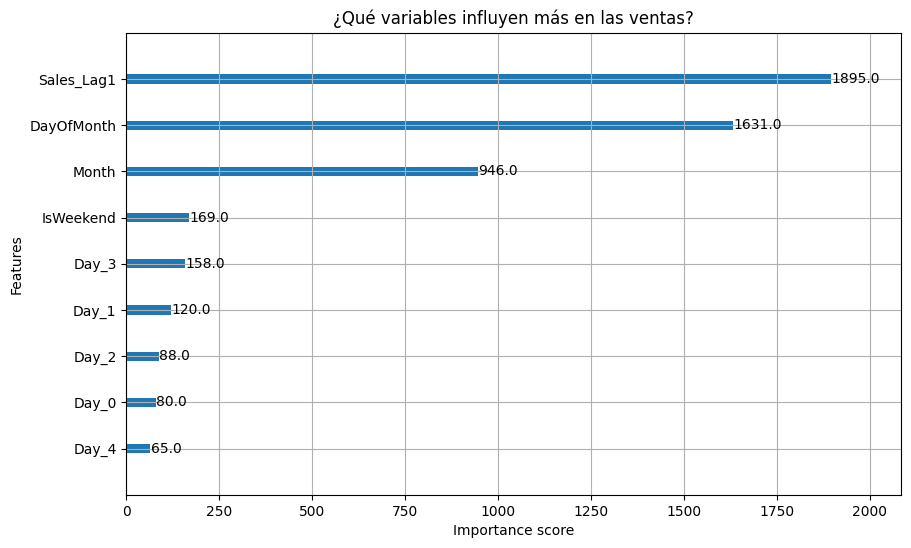

In [6]:
# Generamos una visualización donde vemos la importancia de las variables
plt.figure(figsize=(10, 6))
xg.plot_importance(xgb_model, ax=plt.gca(), importance_type='weight')
plt.title('¿Qué variables influyen más en las ventas?')
plt.show()

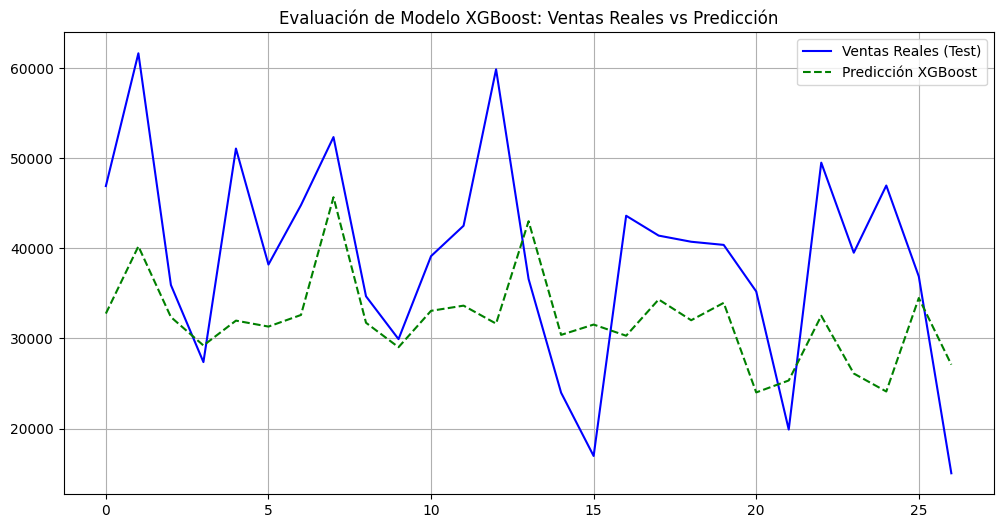

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(test_df.index, y_test, label='Ventas Reales (Test)', color='blue')
plt.plot(test_df.index, test_df['Predictions_XGB'], label='Predicción XGBoost', color='green', linestyle='--')

plt.title('Evaluación de Modelo XGBoost: Ventas Reales vs Predicción')
plt.legend()
plt.grid(True)
plt.show()